
# MMRL vs BayesMMRL 特征分析（仓库直连版）

这个版本不再需要你手写 `build_mmrl_model()` / `build_bayes_model()` / `build_eval_loader()`。

它直接按仓库现有的 `run.py` / `setup_cfg()` / `RefactorRunner` 流程，从
`output_refactor/.../seedX` 的 `case_root` 自动重建 trainer、加载 checkpoint，并读取 `test_loader`。

适用前提：

- 你的仓库结构和当前 MMRL repo 一致
- checkpoint 已经在 `output_refactor/.../seedX/refactor_model/...` 下
- `DATASETS` 目录可访问


In [2]:

from pathlib import Path

# ===== 改这里 =====
REPO_ROOT = Path("/root/autodl-tmp/MMRL").expanduser().resolve()
DATA_ROOT = REPO_ROOT / "DATASETS"

CASES = [
    {
        "name": "MMRL_16shot_seed1",
        "case_root": REPO_ROOT / "output_refactor/MMRL/FS/fewshot_train/caltech101/shots_16/ViT-B-16/default/seed1",
    },
    {
        "name": "BayesMMRL_16shot_seed1",
        "case_root": REPO_ROOT / "output_refactor/BayesMMRL/FS/fewshot_train/caltech101/shots_16/ViT-B-16/default/seed1",
    },
]

SPLIT = "test"
MAX_BATCHES = None
BAYES_N_MC = 10
BAYES_EVAL_MODE = "mc_only"   # "mc_only" | "mean_only" | "mean_plus_mc"

assert REPO_ROOT.exists(), f"REPO_ROOT 不存在: {REPO_ROOT}"
assert DATA_ROOT.exists(), f"DATA_ROOT 不存在: {DATA_ROOT}"
for case in CASES:
    assert Path(case["case_root"]).exists(), f'case_root 不存在: {case["case_root"]}'

print("REPO_ROOT =", REPO_ROOT)
print("DATA_ROOT =", DATA_ROOT)
print("CASES =", len(CASES))


REPO_ROOT = /root/autodl-tmp/MMRL
DATA_ROOT = /root/autodl-tmp/MMRL/DATASETS
CASES = 2


In [3]:

import os
import sys
import math
import importlib
from types import SimpleNamespace

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

os.chdir(REPO_ROOT)

from core.config import setup_cfg
from dassl.engine import build_trainer
from core.utils import import_optional_modules

import_optional_modules([
    'datasets.oxford_pets', 'datasets.oxford_flowers', 'datasets.fgvc_aircraft',
    'datasets.dtd', 'datasets.eurosat', 'datasets.stanford_cars', 'datasets.food101',
    'datasets.sun397', 'datasets.caltech101', 'datasets.ucf101', 'datasets.imagenet',
    'datasets.imagenetv2', 'datasets.imagenet_sketch', 'datasets.imagenet_a', 'datasets.imagenet_r',
])
importlib.import_module('trainers.refactor_runner')

print("torch =", torch.__version__)
print("cuda available =", torch.cuda.is_available())


torch = 2.4.0+cu121
cuda available = True


In [4]:

METHOD_CFG_MAP = {
    "MMRL": "configs/methods/mmrl.yaml",
    "MMRLMix": "configs/methods/mmrl_mix.yaml",
    "MMRLpp": "configs/methods/mmrlpp.yaml",
    "MMRLPP": "configs/methods/mmrlpp.yaml",
    "BayesMMRL": "configs/methods/bayesmmrl.yaml",
    "ClipAdapters": "configs/methods/clip_adapters.yaml",
    "ClipADAPTER": "configs/methods/clip_adapters.yaml",
}

PROTOCOL_CFG_MAP = {
    "B2N": "configs/protocols/b2n.yaml",
    "FS": "configs/protocols/fs.yaml",
    "CD": "configs/protocols/cd.yaml",
}

PROTOCOL_TO_SUBSAMPLE = {
    "B2N": "base",
    "FS": "all",
    "CD": "all",
}

def decode_backbone_from_dir(token: str) -> str:
    if token.startswith("ViT-") and token.count("-") >= 2:
        head, patch = token.rsplit("-", 1)
        return f"{head}/{patch}"
    return token

def infer_case_metadata(case_root: Path):
    case_root = Path(case_root).resolve()
    parts = case_root.parts
    idx = parts.index("output_refactor")

    method = parts[idx + 1]
    protocol = parts[idx + 2]
    phase = parts[idx + 3]
    dataset = parts[idx + 4]
    shots_str = parts[idx + 5]
    backbone_token = parts[idx + 6]
    backbone = decode_backbone_from_dir(backbone_token)
    tag = parts[idx + 7]
    seed_dir = parts[idx + 8]

    shots = int(shots_str.split("_", 1)[1])
    seed = int(seed_dir.replace("seed", ""))

    return {
        "method": method,
        "protocol": protocol,
        "phase": phase,
        "dataset": dataset,
        "shots": shots,
        "backbone": backbone,
        "tag": tag,
        "seed": seed,
        "case_root": case_root,
    }

def make_args_from_case(meta):
    method = meta["method"]
    protocol = meta["protocol"]
    dataset = meta["dataset"]
    shots = meta["shots"]
    backbone = meta["backbone"]
    seed = meta["seed"]
    case_root = meta["case_root"]

    method_cfg = METHOD_CFG_MAP[method]
    protocol_cfg = PROTOCOL_CFG_MAP[protocol]
    subsample = PROTOCOL_TO_SUBSAMPLE[protocol]

    args = SimpleNamespace(
        root=str(DATA_ROOT),
        output_dir=str(case_root),
        dataset_config_file=f"configs/datasets/{dataset}.yaml",
        method_config_file=method_cfg,
        protocol_config_file=protocol_cfg,
        runtime_config_file="configs/runtime/default.yaml",
        exp_config="",
        method=method,
        protocol=protocol,
        exec_mode="online",
        seed=seed,
        trainer="RefactorRunner",
        eval_only=True,
        model_dir=str(case_root),
        load_epoch=None,
        no_train=True,
        opts=[
            "DATASET.NUM_SHOTS", str(shots),
            "DATASET.SUBSAMPLE_CLASSES", str(subsample),
            "MODEL.BACKBONE.NAME", str(backbone),
        ],
    )
    return args

def build_trainer_for_case(case_root: Path):
    meta = infer_case_metadata(case_root)
    args = make_args_from_case(meta)
    cfg = setup_cfg(args)
    trainer = build_trainer(cfg)
    trainer.load_model(str(case_root))
    trainer.set_model_mode("eval")
    return trainer, meta


In [5]:

def top1_conf_margin(logits):
    prob = torch.softmax(logits, dim=-1)
    conf, pred = prob.max(dim=-1)
    top2 = torch.topk(prob, k=min(2, prob.shape[-1]), dim=-1).values
    margin = top2[:, 0] if top2.shape[-1] == 1 else top2[:, 0] - top2[:, 1]
    return pred, conf, margin, prob

def cosine_per_sample(a, b, eps=1e-8):
    a = a / (a.norm(dim=-1, keepdim=True) + eps)
    b = b / (b.norm(dim=-1, keepdim=True) + eps)
    return (a * b).sum(dim=-1)

def sym_kl_from_logits(logits_p, logits_q, eps=1e-8):
    p = torch.softmax(logits_p, dim=-1).clamp_min(eps)
    q = torch.softmax(logits_q, dim=-1).clamp_min(eps)
    kl_pq = (p * (p.log() - q.log())).sum(dim=-1)
    kl_qp = (q * (q.log() - p.log())).sum(dim=-1)
    return 0.5 * (kl_pq + kl_qp)

def js_div_from_logits(logits_p, logits_q, eps=1e-8):
    p = torch.softmax(logits_p, dim=-1).clamp_min(eps)
    q = torch.softmax(logits_q, dim=-1).clamp_min(eps)
    m = 0.5 * (p + q)
    js = 0.5 * (p * (p.log() - m.log())).sum(dim=-1) + 0.5 * (q * (q.log() - m.log())).sum(dim=-1)
    return js

def predictive_entropy_from_probs(probs, eps=1e-8):
    probs = probs.clamp_min(eps)
    return -(probs * probs.log()).sum(dim=-1)

def mutual_information_from_mc_probs(mc_probs, eps=1e-8):
    mean_probs = mc_probs.mean(dim=0)
    pred_ent = predictive_entropy_from_probs(mean_probs, eps=eps)
    exp_ent = predictive_entropy_from_probs(mc_probs, eps=eps).mean(dim=0)
    return pred_ent, exp_ent, pred_ent - exp_ent


In [6]:

@torch.no_grad()
def forward_mmrl_like(model, image):
    model.eval()
    if hasattr(model, "clear_inference_cache"):
        model.clear_inference_cache()

    if hasattr(model, "representation_learner") and hasattr(model, "text_encoder") and hasattr(model, "image_encoder"):
        # BayesMMRL: 直接走 mean_only / mc_only 接口
        if hasattr(model, "forward_eval"):
            old_mode = getattr(model, "eval_mode", None)
            if old_mode is not None:
                model.eval_mode = "mean_only"
            try:
                logits, logits_rep, logits_fusion, image_features, text_features = model.forward_eval(image, num_samples=1)
            finally:
                if old_mode is not None:
                    model.eval_mode = old_mode

            # 额外拿到 image_features_rep
            # 对 Bayes，使用 posterior mean tokens 再过一次 encoder，补齐 rep feature
            rep_text, rep_visual = model.representation_learner.project_mean_tokens()
            text_features2 = model.text_encoder(
                model.prompt_embeddings,
                model.tokenized_prompts,
                rep_text,
            )
            text_features2 = text_features2 / text_features2.norm(dim=-1, keepdim=True)
            image_features2, image_features_rep = model.image_encoder(
                [image.type(model.dtype), list(rep_visual)]
            )
            image_features2 = image_features2 / image_features2.norm(dim=-1, keepdim=True)
            image_features_rep = image_features_rep / image_features_rep.norm(dim=-1, keepdim=True)

            return {
                "logits": logits,
                "logits_rep": logits_rep,
                "logits_fusion": logits_fusion,
                "image_features": image_features2,
                "image_features_rep": image_features_rep,
                "text_features": text_features2,
            }

        # 原始 MMRL 风格
        if not hasattr(model, "text_features_for_inference"):
            raise AttributeError("模型缺少 text_features_for_inference，且也没有 Bayes forward_eval 接口")

        if model.text_features_for_inference is None:
            rep_text, rep_visual = model.representation_learner()
            model.compound_rep_tokens_text_for_inference = rep_text
            model.compound_rep_tokens_visual_for_inference = rep_visual
            model.text_features_for_inference = model.text_encoder(
                model.prompt_embeddings,
                model.tokenized_prompts,
                model.compound_rep_tokens_text_for_inference,
            )

        compound_rep_tokens_visual = model.compound_rep_tokens_visual_for_inference
        text_features = model.text_features_for_inference

        image_features, image_features_rep = model.image_encoder(
            [image.type(model.dtype), compound_rep_tokens_visual]
        )

        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        image_features_rep = image_features_rep / image_features_rep.norm(dim=-1, keepdim=True)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        logits = 100.0 * image_features @ text_features.t()
        logits_rep = 100.0 * image_features_rep @ text_features.t()
        logits_fusion = model.alpha * logits + (1.0 - model.alpha) * logits_rep

        return {
            "logits": logits,
            "logits_rep": logits_rep,
            "logits_fusion": logits_fusion,
            "image_features": image_features,
            "image_features_rep": image_features_rep,
            "text_features": text_features,
        }

    raise RuntimeError("不支持的模型结构")

@torch.no_grad()
def forward_bayes_mc(model, image, n_mc=10, mode="mc_only"):
    if not hasattr(model, "forward_eval"):
        out = forward_mmrl_like(model, image)
        zc = torch.stack([out["logits"]] * n_mc, dim=0)
        zr = torch.stack([out["logits_rep"]] * n_mc, dim=0)
        zf = torch.stack([out["logits_fusion"]] * n_mc, dim=0)
        return zc, zr, zf

    old_mode = getattr(model, "eval_mode", None)
    if old_mode is not None:
        model.eval_mode = mode
    try:
        samples_c, samples_r, samples_f = [], [], []
        for _ in range(n_mc):
            zc, zr, zf, _, _ = model.forward_eval(image, num_samples=1)
            samples_c.append(zc)
            samples_r.append(zr)
            samples_f.append(zf)
        return torch.stack(samples_c, dim=0), torch.stack(samples_r, dim=0), torch.stack(samples_f, dim=0)
    finally:
        if old_mode is not None:
            model.eval_mode = old_mode


In [7]:

@torch.no_grad()
def collect_case_dataframe(trainer, meta, split="test", max_batches=None, bayes_n_mc=10, bayes_eval_mode="mc_only"):
    if split == "val" and trainer.val_loader is not None:
        loader = trainer.val_loader
    else:
        loader = trainer.test_loader
        split = "test"

    model = trainer.method.model
    model.eval()
    if hasattr(model, "clear_inference_cache"):
        model.clear_inference_cache()

    rows = []
    n_seen = 0

    for batch_idx, batch in enumerate(loader):
        if (max_batches is not None) and (batch_idx >= max_batches):
            break

        image = batch["img"].to(trainer.device)
        label = batch["label"].to(trainer.device)

        out = forward_mmrl_like(model, image)

        zc = out["logits"]
        zr = out["logits_rep"]
        zf = out["logits_fusion"]
        fc = out["image_features"]
        fr = out["image_features_rep"]

        pc = F.softmax(zc, dim=1)
        pr = F.softmax(zr, dim=1)
        pf = F.softmax(zf, dim=1)

        pred_c = zc.argmax(dim=1)
        pred_r = zr.argmax(dim=1)
        pred_f = zf.argmax(dim=1)

        feat_cos = F.cosine_similarity(fc, fr, dim=1)
        logit_cos = F.cosine_similarity(zc, zr, dim=1)
        kl_c_r = F.kl_div(pc.log(), pr, reduction="none").sum(dim=1)
        kl_r_c = F.kl_div(pr.log(), pc, reduction="none").sum(dim=1)
        js = 0.5 * (
            F.kl_div(pc.log(), 0.5 * (pc + pr), reduction="none").sum(dim=1)
            + F.kl_div(pr.log(), 0.5 * (pc + pr), reduction="none").sum(dim=1)
        )

        top2_c = zc.topk(2, dim=1).values
        top2_r = zr.topk(2, dim=1).values
        top2_f = zf.topk(2, dim=1).values

        margin_c = top2_c[:, 0] - top2_c[:, 1]
        margin_r = top2_r[:, 0] - top2_r[:, 1]
        margin_f = top2_f[:, 0] - top2_f[:, 1]

        conf_c = pc.max(dim=1).values
        conf_r = pr.max(dim=1).values
        conf_f = pf.max(dim=1).values

        # MC uncertainty
        zc_mc, zr_mc, zf_mc = forward_bayes_mc(model, image, n_mc=bayes_n_mc, mode=bayes_eval_mode)
        pf_mc = torch.softmax(zf_mc, dim=-1)
        logit_std_c = zc_mc.std(dim=0).mean(dim=-1)
        logit_std_r = zr_mc.std(dim=0).mean(dim=-1)
        logit_std_f = zf_mc.std(dim=0).mean(dim=-1)
        pred_entropy_f, expected_entropy_f, mutual_info_f = mutual_information_from_mc_probs(pf_mc)

        for i in range(label.size(0)):
            y = int(label[i].item())
            c = int(pred_c[i].item())
            r = int(pred_r[i].item())
            f = int(pred_f[i].item())

            correct_c = int(c == y)
            correct_r = int(r == y)
            correct_f = int(f == y)

            rows.append({
                "case_name": meta.get("name", meta["case_root"].name),
                "method": meta["method"],
                "protocol": meta["protocol"],
                "dataset": meta["dataset"],
                "shots": meta["shots"],
                "seed": meta["seed"],
                "split": split,
                "index": n_seen,
                "y": y,
                "pred_c": c,
                "pred_r": r,
                "pred_f": f,
                "correct_c": correct_c,
                "correct_r": correct_r,
                "correct_f": correct_f,
                "both_correct": int(correct_c == 1 and correct_r == 1),
                "c_only": int(correct_c == 1 and correct_r == 0),
                "r_only": int(correct_c == 0 and correct_r == 1),
                "both_wrong": int(correct_c == 0 and correct_r == 0),
                "agree_argmax": int(c == r),
                "logit_cos": float(logit_cos[i].item()),
                "feat_cos": float(feat_cos[i].item()),
                "kl_c_r": float(kl_c_r[i].item()),
                "kl_r_c": float(kl_r_c[i].item()),
                "sym_kl": float(0.5 * (kl_c_r[i].item() + kl_r_c[i].item())),
                "js_div": float(js[i].item()),
                "margin_c": float(margin_c[i].item()),
                "margin_r": float(margin_r[i].item()),
                "margin_f": float(margin_f[i].item()),
                "conf_c": float(conf_c[i].item()),
                "conf_r": float(conf_r[i].item()),
                "conf_f": float(conf_f[i].item()),
                "fusion_beats_c": int((correct_f == 1) and (correct_c == 0)),
                "fusion_beats_r": int((correct_f == 1) and (correct_r == 0)),
                "fusion_beats_both": int((correct_f == 1) and (correct_c == 0) and (correct_r == 0)),
                "hurt_c": int((correct_c == 1) and (correct_f == 0)),
                "hurt_r": int((correct_r == 1) and (correct_f == 0)),
                "hurt_best_branch": int(((correct_c == 1) or (correct_r == 1)) and (correct_f == 0)),
                "logit_std_c": float(logit_std_c[i].item()),
                "logit_std_r": float(logit_std_r[i].item()),
                "logit_std_f": float(logit_std_f[i].item()),
                "pred_entropy_f": float(pred_entropy_f[i].item()),
                "expected_entropy_f": float(expected_entropy_f[i].item()),
                "mutual_info_f": float(mutual_info_f[i].item()),
            })
            n_seen += 1

    return pd.DataFrame(rows)


In [8]:

all_dfs = []
trainers = {}
metas = {}

for case in CASES:
    case_root = Path(case["case_root"]).resolve()
    trainer, meta = build_trainer_for_case(case_root)
    meta["name"] = case["name"]
    trainers[case["name"]] = trainer
    metas[case["name"]] = meta

    df_case = collect_case_dataframe(
        trainer=trainer,
        meta=meta,
        split=SPLIT,
        max_batches=MAX_BATCHES,
        bayes_n_mc=BAYES_N_MC,
        bayes_eval_mode=BAYES_EVAL_MODE,
    )
    all_dfs.append(df_case)

df_all = pd.concat(all_dfs, axis=0, ignore_index=True)
print(df_all.shape)
df_all.head()


Loading trainer: RefactorRunner
Loading dataset: Caltech101
Reading split from /root/autodl-tmp/MMRL/DATASETS/caltech-101/split_zhou_Caltech101.json
Loading preprocessed few-shot data from /root/autodl-tmp/MMRL/DATASETS/caltech-101/split_fewshot/shot_16-seed_1.pkl
Building transform_train
+ random resized crop (size=(224, 224), scale=(0.5, 1))
+ random flip
+ to torch tensor of range [0, 1]
+ normalization (mean=[0.48145466, 0.4578275, 0.40821073], std=[0.26862954, 0.26130258, 0.27577711])
Building transform_test
+ resize the smaller edge to 224
+ 224x224 center crop
+ to torch tensor of range [0, 1]
+ normalization (mean=[0.48145466, 0.4578275, 0.40821073], std=[0.26862954, 0.26130258, 0.27577711])
---------  ----------
Dataset    Caltech101
# classes  100
# train_x  1,600
# val      400
# test     2,465
---------  ----------
[MMRL] trainable params: {'representation_learner.compound_rep_tokens_r2tproj.4.weight', 'representation_learner.compound_rep_tokens_r2vproj.3.weight', 'represen

/root/miniconda3/envs/mmrl/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
/root/autodl-tmp/MMRL/trainers/refactor_runner.py:52: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = GradScaler() if prec == "amp" else None
/root/autodl-tmp/Dassl.pytorch/dassl/utils/torchtools.py:102: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpic

Loading weights to refactor_model from "/root/autodl-tmp/MMRL/output_refactor/MMRL/FS/fewshot_train/caltech101/shots_16/ViT-B-16/default/seed1/refactor_model/model.pth.tar-50" (epoch = 50)
Loading trainer: RefactorRunner
Loading dataset: Caltech101
Reading split from /root/autodl-tmp/MMRL/DATASETS/caltech-101/split_zhou_Caltech101.json
Loading preprocessed few-shot data from /root/autodl-tmp/MMRL/DATASETS/caltech-101/split_fewshot/shot_16-seed_1.pkl
Building transform_train
+ random resized crop (size=(224, 224), scale=(0.5, 1))
+ random flip
+ to torch tensor of range [0, 1]
+ normalization (mean=[0.48145466, 0.4578275, 0.40821073], std=[0.26862954, 0.26130258, 0.27577711])
Building transform_test
+ resize the smaller edge to 224
+ 224x224 center crop
+ to torch tensor of range [0, 1]
+ normalization (mean=[0.48145466, 0.4578275, 0.40821073], std=[0.26862954, 0.26130258, 0.27577711])
---------  ----------
Dataset    Caltech101
# classes  100
# train_x  1,600
# val      400
# test     

,case_name,method,protocol,dataset,shots,seed,split,index,y,pred_c,...,fusion_beats_both,hurt_c,hurt_r,hurt_best_branch,logit_std_c,logit_std_r,logit_std_f,pred_entropy_f,expected_entropy_f,mutual_info_f
0,MMRL_16shot_seed1,MMRL,FS,caltech101,16,1,test,0,0,0,...,0,0,0,0,0.0,0.0,0.0,0.043167,0.043167,-3.725290e-09
1,MMRL_16shot_seed1,MMRL,FS,caltech101,16,1,test,1,0,0,...,0,0,0,0,0.0,0.0,0.0,0.055716,0.055716,-5.587935e-08
2,MMRL_16shot_seed1,MMRL,FS,caltech101,16,1,test,2,0,0,...,0,0,0,0,0.0,0.0,0.0,0.059455,0.059455,0.000000e+00
3,MMRL_16shot_seed1,MMRL,FS,caltech101,16,1,test,3,0,0,...,0,0,0,0,0.0,0.0,0.0,0.300671,0.300671,0.000000e+00
4,MMRL_16shot_seed1,MMRL,FS,caltech101,16,1,test,4,0,0,...,0,0,0,0,0.0,0.0,0.0,0.088456,0.088456,0.000000e+00


In [9]:

def summarize_case(df_case):
    return pd.Series({
        "n": len(df_case),
        "acc_c": df_case["correct_c"].mean(),
        "acc_r": df_case["correct_r"].mean(),
        "acc_f": df_case["correct_f"].mean(),
        "both_correct": df_case["both_correct"].mean(),
        "c_only": df_case["c_only"].mean(),
        "r_only": df_case["r_only"].mean(),
        "both_wrong": df_case["both_wrong"].mean(),
        "complementarity": df_case["c_only"].mean() + df_case["r_only"].mean(),
        "agree_rate": df_case["agree_argmax"].mean(),
        "mean_logit_cos": df_case["logit_cos"].mean(),
        "mean_feat_cos": df_case["feat_cos"].mean(),
        "mean_sym_kl": df_case["sym_kl"].mean(),
        "mean_js_div": df_case["js_div"].mean(),
        "fusion_beats_c": df_case["fusion_beats_c"].mean(),
        "fusion_beats_r": df_case["fusion_beats_r"].mean(),
        "fusion_beats_both": df_case["fusion_beats_both"].mean(),
        "hurt_c": df_case["hurt_c"].mean(),
        "hurt_r": df_case["hurt_r"].mean(),
        "hurt_best_branch": df_case["hurt_best_branch"].mean(),
        "mean_margin_c": df_case["margin_c"].mean(),
        "mean_margin_r": df_case["margin_r"].mean(),
        "mean_margin_f": df_case["margin_f"].mean(),
        "mean_conf_c": df_case["conf_c"].mean(),
        "mean_conf_r": df_case["conf_r"].mean(),
        "mean_conf_f": df_case["conf_f"].mean(),
        "mean_logit_std_f": df_case["logit_std_f"].mean(),
        "mean_mutual_info_f": df_case["mutual_info_f"].mean(),
    })

summary = df_all.groupby("case_name", sort=False).apply(summarize_case).reset_index()
summary


/tmp/ipykernel_136880/2286402324.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df_all.groupby("case_name", sort=False).apply(summarize_case).reset_index()


,case_name,n,acc_c,acc_r,acc_f,both_correct,c_only,r_only,both_wrong,complementarity,...,hurt_r,hurt_best_branch,mean_margin_c,mean_margin_r,mean_margin_f,mean_conf_c,mean_conf_r,mean_conf_f,mean_logit_std_f,mean_mutual_info_f
0,MMRL_16shot_seed1,2465.0,0.965112,0.958621,0.969574,0.945639,0.019473,0.012982,0.021907,0.032454,...,0.005680,0.008925,6.614792,8.677811,7.656488,0.964439,0.975788,0.974379,0.000000,-1.411584e-08
1,BayesMMRL_16shot_seed1,2465.0,0.963083,0.953753,0.968357,0.937931,0.025152,0.015822,0.021095,0.040974,...,0.006085,0.011359,6.402562,8.826004,7.564540,0.954763,0.973906,0.969796,0.207214,1.213527e-03


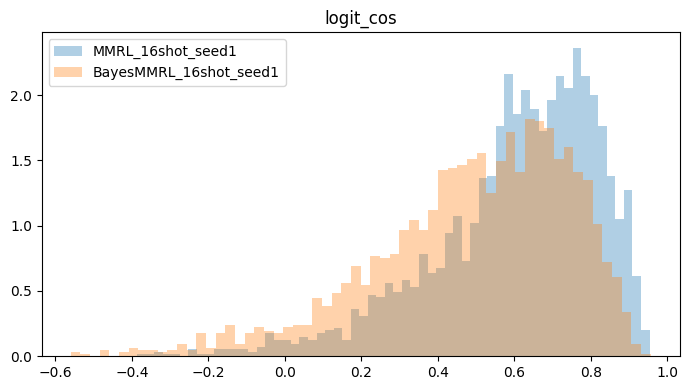

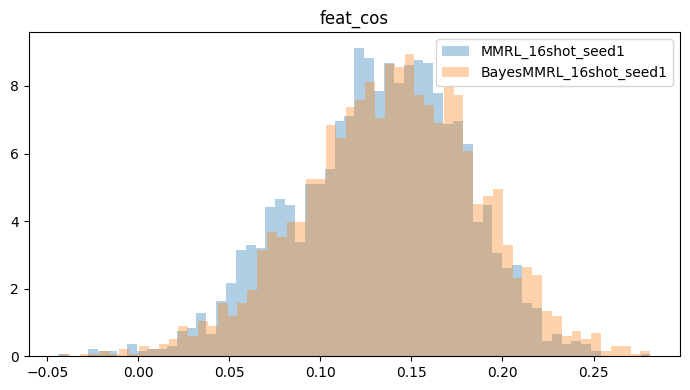

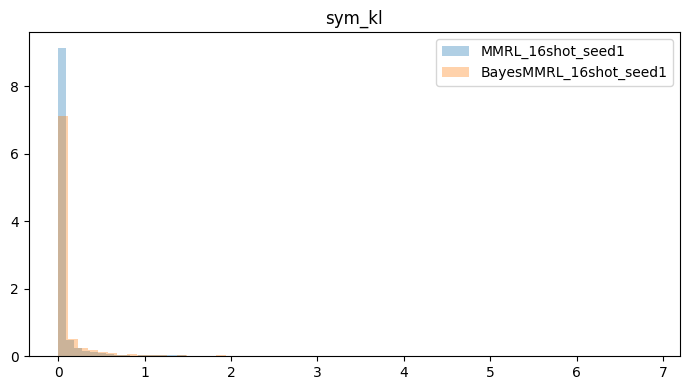

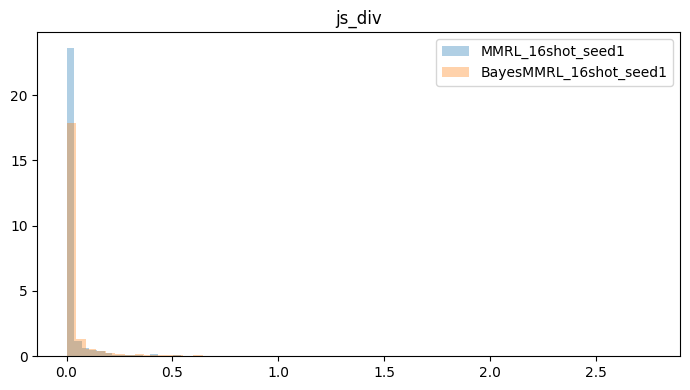

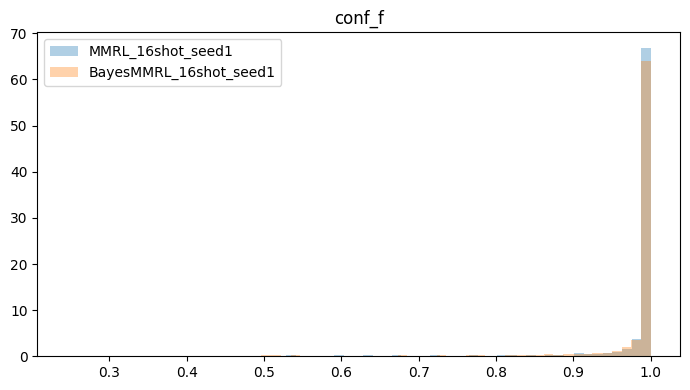

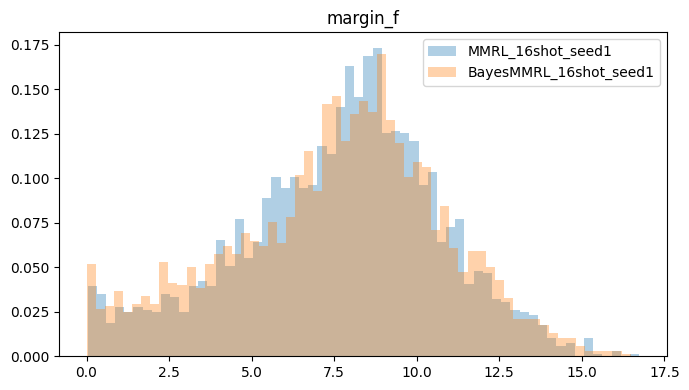

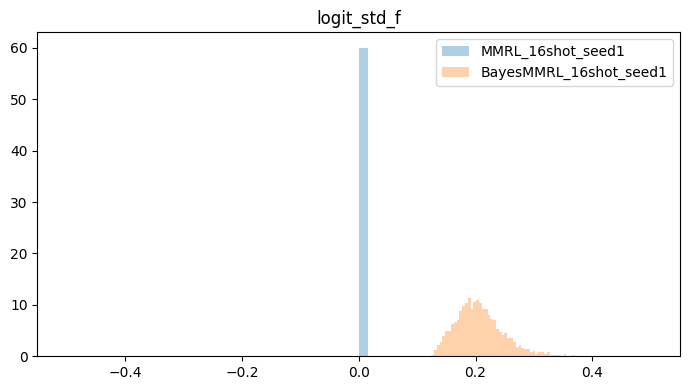

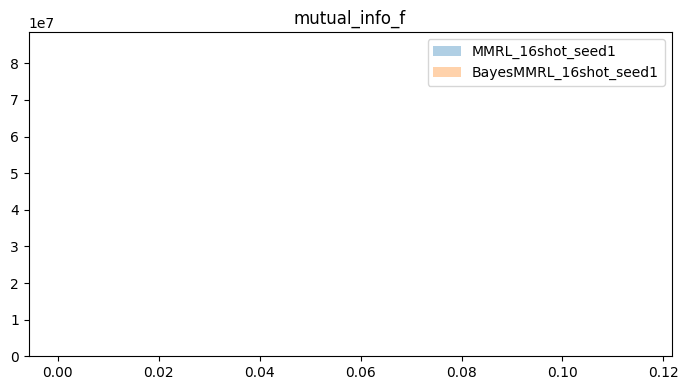

In [10]:

def plot_case_distributions(df_all, metric, bins=60, figsize=(7, 4)):
    cases = list(df_all["case_name"].unique())
    plt.figure(figsize=figsize)
    for case in cases:
        x = df_all.loc[df_all["case_name"] == case, metric].values
        plt.hist(x, bins=bins, alpha=0.35, density=True, label=case)
    plt.title(metric)
    plt.legend()
    plt.tight_layout()
    plt.show()

for metric in [
    "logit_cos", "feat_cos", "sym_kl", "js_div",
    "conf_f", "margin_f", "logit_std_f", "mutual_info_f"
]:
    plot_case_distributions(df_all, metric)



## 怎么看 MMRL vs BayesMMRL

优先看：

- `acc_f`
- `complementarity`
- `mean_logit_cos`
- `mean_feat_cos`
- `mean_sym_kl`
- `fusion_beats_both`
- `hurt_best_branch`
- `mean_logit_std_f`
- `mean_mutual_info_f`

经验上：

- 如果 BayesMMRL 的 `acc_f` 上升，同时 `hurt_best_branch` 下降，通常说明 Bayes 的随机共享表征在做“稳健纠错”
- 如果 `mean_logit_cos` / `mean_feat_cos` 明显下降，往往说明 Bayes 减轻了分支塌缩
- 如果 `complementarity` 保持住或略升，说明 Bayes 没把两条分支学成一条
- 如果 `mean_logit_std_f`、`mean_mutual_info_f` 适中而不是异常大，通常表示不确定性建模比较健康
